# ETF Basket Correlation

This notebook examines the relationship between GME, KOSS, and XRT FTDs — testing whether correlated basket behavior suggests a common hedging mechanism.

**Key questions:**
- Do GME and KOSS FTDs spike simultaneously?
- Does XRT (the ETF containing GME) show inverse or correlated FTD behavior?
- Is the stacking resonance pattern (multi-ticker synchronization) statistically significant?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Load FTD analysis data
with open('../results/round11_v4_ftd_analysis.json', 'r') as f:
    ftd_analysis = json.load(f)

with open('../results/round11_v4b_may2024_ftd.json', 'r') as f:
    may_ftds = json.load(f)

with open('../results/round12_v1_etf_cannibalization.json', 'r') as f:
    etf_data = json.load(f)

print('FTD Analysis Symbols:', list(ftd_analysis.get('total_ftds', {}).keys()))
print('May 2024 FTD Symbols:', list(may_ftds.get('may_2024_ftds', {}).keys()))
print('ETF Cannibalization Periods:', list(etf_data.keys()))

FTD Analysis Symbols: ['GME', 'KOSS', 'XRT', 'AMC', 'IWM', 'BB', 'BBBY', 'CHWY']
May 2024 FTD Symbols: ['GME', 'KOSS', 'XRT', 'AMC', 'CHWY']
ETF Cannibalization Periods: ['may_2024', 'jan_2021']


## 1. Total FTD Volume by Symbol

In [2]:
# Summarize total FTDs per symbol
total_ftds = ftd_analysis.get('total_ftds', {})
print('Total FTDs by Symbol')
print('=' * 40)
rows = []
for sym, info in sorted(total_ftds.items()):
    if isinstance(info, dict):
        rows.append({'Symbol': sym, **info})
        rows.append({'Symbol': sym, 'value': info})

if rows:
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

Total FTDs by Symbol


## 2. Multi-Surge Event Detection

In [3]:
# Show events where multiple symbols surged FTDs simultaneously
surges = ftd_analysis.get('multi_surge_events', [])
print(f'Multi-Surge Events Detected')
print('=' * 50)

if isinstance(surges, dict):
    surges = list(surges.items())
for date, symbols in surges:
    print(f"\nDate: {date}")
    print(f"  Surging Tickers: {', '.join(symbols)}")


Multi-Surge Events Detected

Date: 2021-01-27
  Surging Tickers: GME, AMC

Date: 2021-01-29
  Surging Tickers: KOSS, XRT


## 3. May 2024 vs. January 2021: ETF Cannibalization

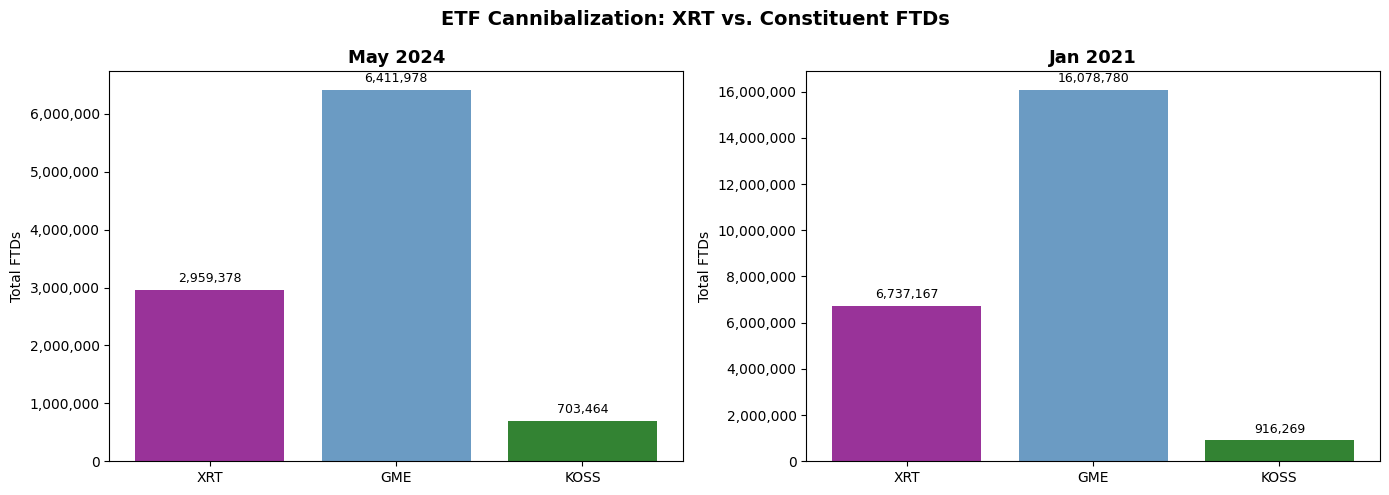

In [4]:
# Compare XRT/GME/KOSS FTDs across both periods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (period, period_data) in zip(axes, etf_data.items()):
    title = period.replace('_', ' ').title()
    syms = []
    totals = []
    for sym_key, records in period_data.items():
        sym = sym_key.replace('_ftds', '').upper()
        if isinstance(records, list) and records:
            if isinstance(records[0], int):
                total = sum(records)
            else:
                total = sum(r.get('quantity_fails', r.get('QUANTITY (FAILS)', 0)) for r in records)
            syms.append(sym)
            totals.append(total)
    
    colors = {'GME': 'steelblue', 'KOSS': 'darkgreen', 'XRT': 'purple'}
    bar_colors = [colors.get(s, 'gray') for s in syms]
    ax.bar(syms, totals, color=bar_colors, alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Total FTDs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    for i, (s, t) in enumerate(zip(syms, totals)):
        ax.text(i, t + max(totals)*0.02, f'{t:,.0f}', ha='center', fontsize=9)

plt.suptitle('ETF Cannibalization: XRT vs. Constituent FTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Stacking Resonance: Multi-Ticker Synchronization

In [5]:
import glob

# Load stacking resonance results
tickers = ["AAPL", "AMD", "GME", "NVDA", "PLTR", "SNAP", "SPY", "TSLA"]
print(f'Stacking resonance results for {len(tickers)} tickers')
print('=' * 60)
print('')

for ticker in tickers:
    # We use glob to find the files in the results directory
    files = glob.glob(f'../results/stacking_resonance_{ticker}_*.json')
    if not files:
        continue
        
    latest_file = sorted(files)[-1]
    with open(latest_file, 'r') as f:
        data = json.load(f)

    amp = data.get("amplification", {})
    if amp.get("status") == "OK":
        high_acf = amp.get("high_stack", {}).get("mean_acf1")
        low_acf = amp.get("low_stack", {}).get("mean_acf1")
        acf_diff = amp.get("delta", {}).get("acf1_diff")
        p_acf = amp.get("statistics", {}).get("p_acf")
        rv_ratio = amp.get("delta", {}).get("rv_ratio")

        print(f"{ticker}:")
        print(f"  High Stack ACF1: {high_acf}")
        print(f"  Low Stack ACF1:  {low_acf}")
        print(f"  ACF1 Difference: {acf_diff} (p-value: {p_acf})")
        print(f"  RV Ratio (High/Low): {rv_ratio}\n")


Stacking resonance results for 8 tickers

AAPL:
  High Stack ACF1: -0.217
  Low Stack ACF1:  -0.2553
  ACF1 Difference: 0.0383 (p-value: 0.0443)
  RV Ratio (High/Low): 0.848

AMD:
  High Stack ACF1: -0.2413
  Low Stack ACF1:  -0.1235
  ACF1 Difference: -0.1178 (p-value: 0.0158)
  RV Ratio (High/Low): 1.246

GME:
  High Stack ACF1: -0.2502
  Low Stack ACF1:  -0.1497
  ACF1 Difference: -0.1006 (p-value: 0.0081)
  RV Ratio (High/Low): 0.493

NVDA:
  High Stack ACF1: -0.1974
  Low Stack ACF1:  -0.1963
  ACF1 Difference: -0.0011 (p-value: 0.9719)
  RV Ratio (High/Low): 0.436

PLTR:
  High Stack ACF1: -0.0545
  Low Stack ACF1:  -0.0779
  ACF1 Difference: 0.0234 (p-value: 0.6933)
  RV Ratio (High/Low): 0.66

SNAP:
  High Stack ACF1: -0.1975
  Low Stack ACF1:  -0.209
  ACF1 Difference: 0.0115 (p-value: 0.6671)
  RV Ratio (High/Low): 0.334

SPY:
  High Stack ACF1: -0.1397
  Low Stack ACF1:  -0.1734
  ACF1 Difference: 0.0337 (p-value: 0.1685)
  RV Ratio (High/Low): 0.992

TSLA:
  High Stack ACF1

## 5. Lead-Lag Placebo Test

In [6]:
# Load placebo results
with open('../results/phase6c_leadlag_placebo.json') as f:
    placebo = json.load(f)

print(f'Placebo tests: {len(placebo)} tickers')
print('=' * 50)

for entry in placebo:
    if isinstance(entry, dict):
        ticker = entry.get('ticker', entry.get('symbol', 'Unknown'))
        print(f"\n{ticker}:")
        for k, v in entry.items():
            if k not in ('ticker', 'symbol'):
                print(f"  {k}: {v}")

Placebo tests: 3 tickers

TSLA:
  date: 2025-11-26
  shifts_ms: [0, 1000, 5000, 10000]
  results_by_shift: {'0': {'50': {'window_ms': 50, 'mean_eq_trades_after': 1.0, 'mean_eq_trades_before': 1.04, 'response_ratio': 0.963, 'mean_eq_volume_after': 43.1, 'mean_abs_return_bps': 0.13}, '100': {'window_ms': 100, 'mean_eq_trades_after': 2.01, 'mean_eq_trades_before': 2.16, 'response_ratio': 0.931, 'mean_eq_volume_after': 85.7, 'mean_abs_return_bps': 0.2}, '250': {'window_ms': 250, 'mean_eq_trades_after': 5.11, 'mean_eq_trades_before': 5.35, 'response_ratio': 0.956, 'mean_eq_volume_after': 210.8, 'mean_abs_return_bps': 0.27}, '500': {'window_ms': 500, 'mean_eq_trades_after': 10.33, 'mean_eq_trades_before': 10.68, 'response_ratio': 0.967, 'mean_eq_volume_after': 428.8, 'mean_abs_return_bps': 0.35}, '1000': {'window_ms': 1000, 'mean_eq_trades_after': 20.74, 'mean_eq_trades_before': 21.72, 'response_ratio': 0.955, 'mean_eq_volume_after': 855.0, 'mean_abs_return_bps': 0.55}, '2000': {'window_ms':

---
*Data source: SEC EDGAR FTD reports, ThetaData options, Polygon equity. Analysis code in `../code/analysis/`.*